In [1]:
import sys 
import os

In [2]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import yaml
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [9]:
import statsmodels.api as sm

In [4]:
yaml_path = rf"..\config\config.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [5]:
yaml_path = rf"..\config\model.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config_model = yaml.safe_load(f)

# Params

# Read Train / val dataset

In [6]:
pipeline_name="Pipeline1"

In [7]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')  

X_val = pd.read_parquet(fr'..\data\feature_eng\X_val_feat_eng_{pipeline_name}.parquet')
y_val = pd.read_parquet(fr'..\data\feature_eng\y_val_feat_eng_{pipeline_name}.parquet')

# Drop columns

In [8]:
X_train.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)

X_val.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)


In [10]:
X_train

,num_con_1_pipe__LotArea,num_con_1_pipe__GrLivArea,num_con_2_pipe__MasVnrArea,num_con_2_pipe__BsmtFinSF1,num_con_2_pipe__2ndFlrSF,num_con_2_pipe__GarageArea,num_dis_pipe__OverallQual,num_dis_pipe__FullBath,num_dis_pipe__HalfBath,num_dis_pipe__BedroomAbvGr,...,categorical_pipe__Neighborhood_NAmes,categorical_pipe__ExterQual_TA,categorical_pipe__BsmtQual_Gd,categorical_pipe__BsmtCond_TA,categorical_pipe__BsmtExposure_No,categorical_pipe__BsmtExposure_Av,categorical_pipe__KitchenQual_Gd,categorical_pipe__SaleType_WD,categorical_pipe__SaleCondition_Normal,num_con_1_robust__TotalBsmtSF
254,17.195067,8.247752,0,7,0,7,5,1,0,3,...,1,1,0,1,1,0,0,1,1,0.616177
1066,16.971792,8.482770,0,0,8,8,6,2,1,3,...,0,0,1,1,1,0,0,1,1,-0.445131
638,17.337405,7.596716,0,0,0,0,5,1,0,2,...,0,1,0,1,1,0,0,1,1,-0.451314
799,16.701672,8.639066,7,7,8,7,5,1,1,3,...,0,1,1,1,1,0,1,1,1,-0.585265
380,15.573121,8.580072,0,6,8,7,5,2,0,3,...,0,1,0,1,1,0,1,1,1,0.022669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,17.532284,8.247752,0,3,0,8,6,2,0,3,...,0,0,1,1,1,0,1,1,1,0.616177
1130,16.958276,8.790222,0,7,8,8,4,2,0,4,...,0,1,0,1,1,0,1,1,1,0.220505
1294,17.106263,7.702349,0,5,0,8,5,1,0,2,...,0,1,0,1,1,0,0,1,1,-0.311180
860,16.891196,8.355170,0,0,8,7,7,1,1,3,...,0,0,0,1,1,0,1,1,1,-0.212262


# Features

## LotArea

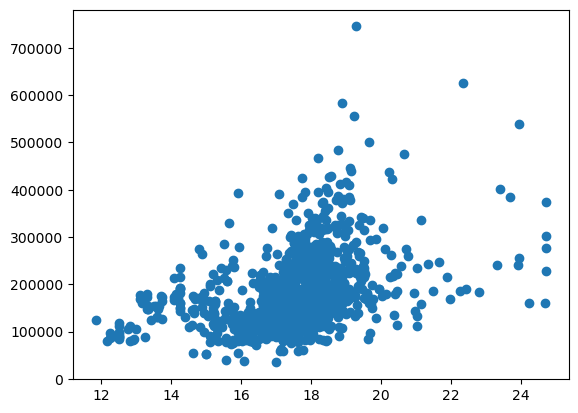

In [11]:
plt.scatter(
    x=X_train['num_con_1_pipe__LotArea'],
    y=y_train
                );

In [13]:
X = X_train['num_con_1_pipe__LotArea'].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     230.5
Date:                seg, 11 mai 2026   Prob (F-statistic):           1.24e-47
Time:                        18:49:04   Log-Likelihood:                -14697.
No. Observations:                1168   AIC:                         2.940e+04
Df Residuals:                    1166   BIC:                         2.941e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                   -1

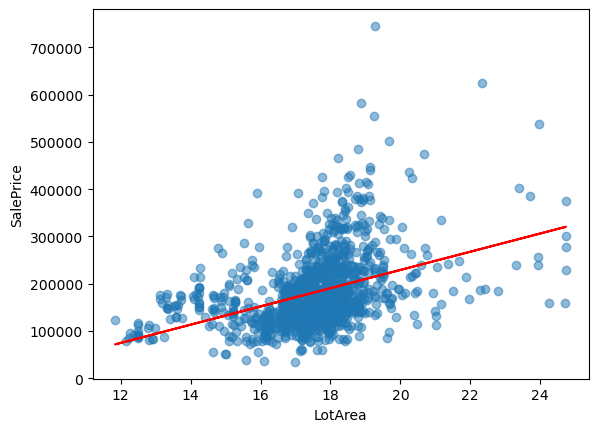

In [18]:
plt.scatter(
    x=X_train['num_con_1_pipe__LotArea'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train['num_con_1_pipe__LotArea'],
    results.fittedvalues,
    color='red'
)

plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()

## GrLivArea

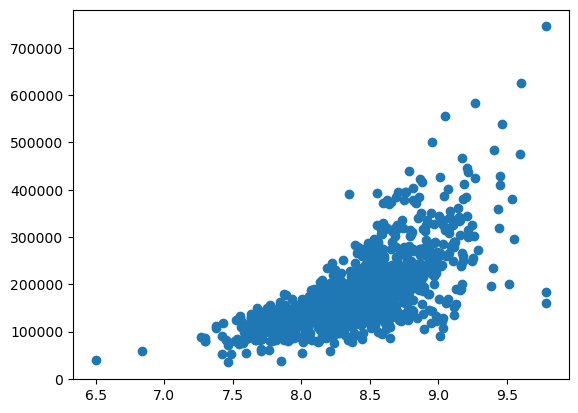

In [19]:
plt.scatter(
    x=X_train['num_con_1_pipe__GrLivArea'],
    y=y_train
                );

In [20]:
X = X_train['num_con_1_pipe__GrLivArea'].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     1083.
Date:                seg, 11 mai 2026   Prob (F-statistic):          1.46e-168
Time:                        18:53:54   Log-Likelihood:                -14419.
No. Observations:                1168   AIC:                         2.884e+04
Df Residuals:                    1166   BIC:                         2.885e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

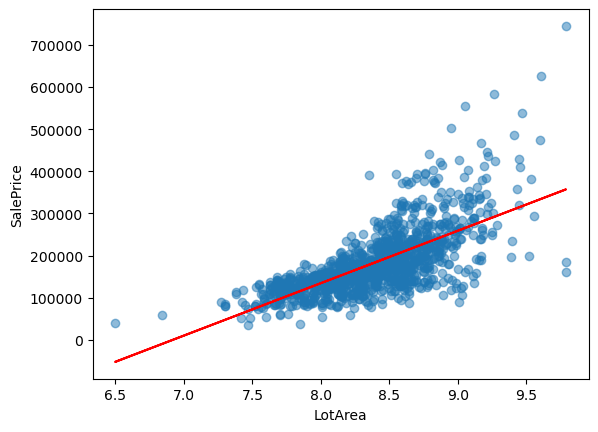

In [21]:
plt.scatter(
    x=X_train['num_con_1_pipe__GrLivArea'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train['num_con_1_pipe__GrLivArea'],
    results.fittedvalues,
    color='red'
)

plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.show()

## TotalBsmtSF

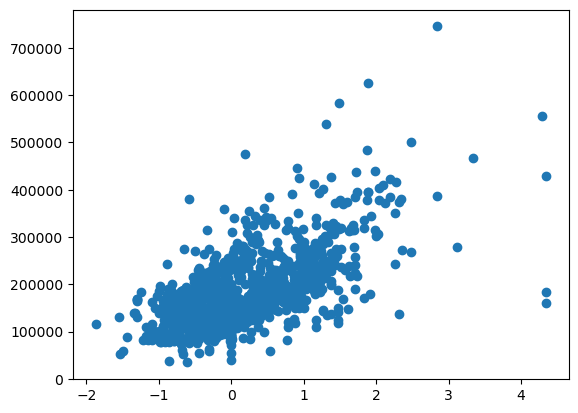

In [25]:
plt.scatter(
    x=X_train['num_con_1_robust__TotalBsmtSF'],
    y=y_train
                );

In [26]:
X = X_train['num_con_1_robust__TotalBsmtSF'].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     738.6
Date:                seg, 11 mai 2026   Prob (F-statistic):          2.18e-126
Time:                        18:56:12   Log-Likelihood:                -14516.
No. Observations:                1168   AIC:                         2.904e+04
Df Residuals:                    1166   BIC:                         2.905e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

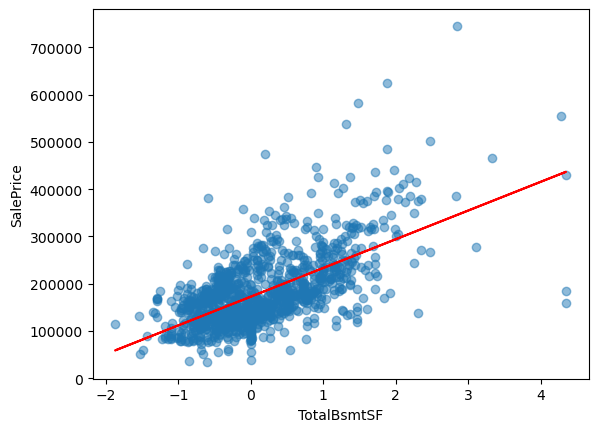

In [27]:
plt.scatter(
    x=X_train['num_con_1_robust__TotalBsmtSF'],
    y=y_train,
    alpha=0.5
)

plt.plot(
    X_train['num_con_1_robust__TotalBsmtSF'],
    results.fittedvalues,
    color='red'
)

plt.xlabel('TotalBsmtSF')
plt.ylabel('SalePrice')
plt.show()

 ## TotalBsmtSF e  GrLivArea

In [ ]:
X = X_train[['num_con_1_robust__TotalBsmtSF', 'num_con_1_pipe__GrLivArea']].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     927.6
Date:                seg, 11 mai 2026   Prob (F-statistic):          1.02e-241
Time:                        19:00:38   Log-Likelihood:                -14246.
No. Observations:                1168   AIC:                         2.850e+04
Df Residuals:                    1165   BIC:                         2.851e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

 ## TotalBsmtSF ,  GrLivArea e LotArea

In [29]:
X = X_train[['num_con_1_robust__TotalBsmtSF', 'num_con_1_pipe__GrLivArea', 'num_con_1_pipe__LotArea']].copy()
X = sm.add_constant(X)

linreg = sm.OLS(y_train.values, X)
results = linreg.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     623.3
Date:                seg, 11 mai 2026   Prob (F-statistic):          1.56e-241
Time:                        19:02:03   Log-Likelihood:                -14243.
No. Observations:                1168   AIC:                         2.849e+04
Df Residuals:                    1164   BIC:                         2.851e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         